In [25]:
from pathlib import Path
import glob
import os
import numpy as np
import cv2
from scipy.ndimage import distance_transform_edt, label
from tqdm import tqdm

In [26]:
script_dir = Path.cwd()
img_dir = os.path.join(script_dir, "training_data")
IMAGE_PATH = sorted(glob.glob("./images/*/*_main.jpg"))
MASK_PATH = sorted(glob.glob("./masks/*/*_mask.jpg"))


In [27]:
def heatmap_transform(CURRENT_IMAGE, CURRENT_MASK):
    binary_mask = cv2.imread(CURRENT_MASK, 0)
    binary_mask = (binary_mask > 127).astype(np.uint8)
    # Load Mask
    kernel = np.ones((3, 3), np.uint8)
    mask_for_labeling = cv2.erode(binary_mask, kernel, iterations=2)
    instance_map, num_features = label(mask_for_labeling)

    #Generate Distance Transform
    distance_map = np.zeros_like(instance_map, dtype=np.float32)
    for i in range(1, num_features + 1):
        # Create a mask for just this object
        obj_mask = (instance_map == i)
        # Euclidean Distance Transform computes distance to zero regions
        dist = distance_transform_edt(obj_mask)
        obj_max = dist.max()
        dt_norm = dist / obj_max
        distance_map += (dt_norm * 15)

    # Smooth
    distance_map = cv2.GaussianBlur(distance_map, (15, 15), 0)
    distance_map = distance_map * (instance_map > 0)

    # --Directional Vector--
    # Calculate the numerical gradient (derivative) of an N-dimensional array
    dy, dx = np.gradient(distance_map)

    # Normalize to create unit vectors + epsilon
    magnitude = np.sqrt(dx ** 2 + dy ** 2) + 1e-8
    magnitude[magnitude == 0] = 1 # Avoid division by zero

    u_x = dx / magnitude
    u_y = dy / magnitude

    # Mask out background
    u_x[binary_mask == 0] = 0
    u_y[binary_mask == 0] = 0

    # --Generate Discretized Energy Map--
    direction_target = np.stack([u_x, u_y], axis=0)
    # Energy Labels
    quantized_e = np.floor(distance_map).astype(np.int64)
    quantized_e = np.clip(quantized_e, 0, 15)
    quantized_e[binary_mask == 0] = 0
    energy_target = quantized_e
    return direction_target, energy_target

In [28]:
from pathlib import Path
import matplotlib.pyplot as plt

direction = None
energy = None
for rgb_path in IMAGE_PATH:
    # Removes '_main'
    rgb_id = Path(rgb_path).stem.replace("_main", "")

    for mask_path in MASK_PATH:
        mask_id = Path(mask_path).stem.replace("_mask", "")
        if rgb_id == mask_id:
            direction, energy = heatmap_transform(rgb_path, mask_path)
            break # Move to the next RGB image once a mask is found
    break

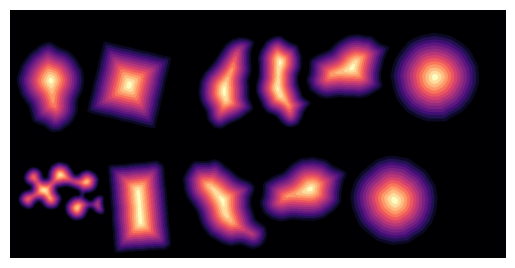

In [29]:
plt.imshow(energy, cmap="magma")
plt.axis("off")
plt.savefig("discretised_energy.png")
plt.show()

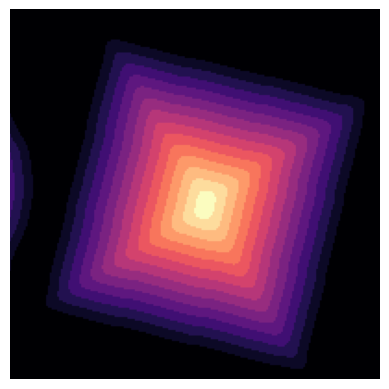

In [75]:
plt.imshow(energy, cmap="magma")
plt.xlim(140, 340)
plt.ylim(250, 50)
plt.axis("off")
plt.show()

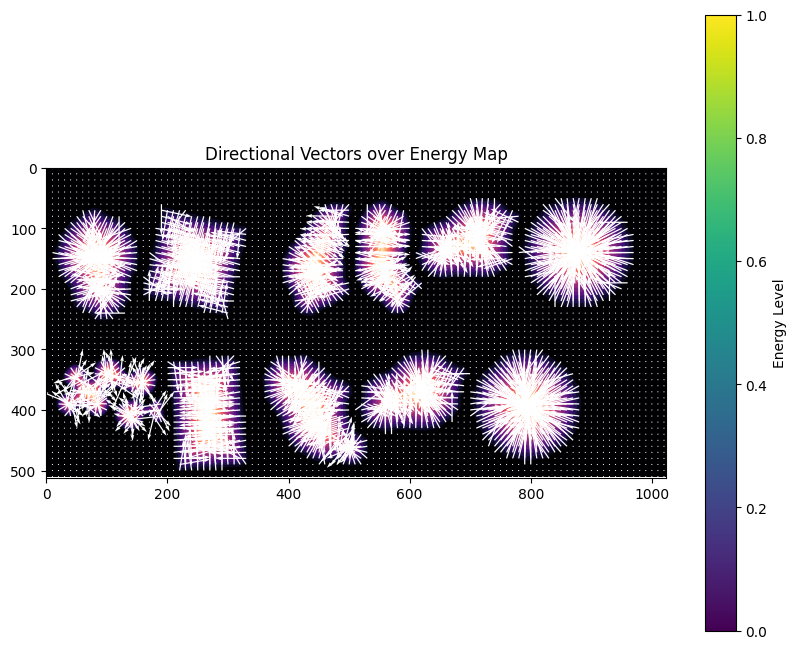

In [30]:
# Get targets
direction_target, energy_target = direction, energy

# Unpack the components
# direction_target[0] is u_x, direction_target[1] is u_y
u_x = direction_target[0]
u_y = direction_target[1]

# Create a coordinate grid
h, w = energy_target.shape
x, y = np.meshgrid(np.arange(w), np.arange(h))

# Subsample for clarity
step = 10
sub_x = x[::step, ::step]
sub_y = y[::step, ::step]
sub_u = u_x[::step, ::step]
sub_v = u_y[::step, ::step]

# Plotting
plt.figure(figsize=(10, 8))

# Show the energy map as the background
plt.imshow(energy_target, cmap='magma')

# Overlay the direction vectors
plt.quiver(sub_x, sub_y, sub_u, -sub_v, color='white', scale=20, width=0.002)

plt.title("Directional Vectors over Energy Map")
plt.colorbar(label='Energy Level')
plt.show()

In [7]:
import numpy as np
import glob
import os
from pathlib import Path

# Get the lists
IMAGE_PATH = sorted(glob.glob("./5-Set Dataset PNG/validation_data/images/*/*_main.png"))
MASK_PATH = sorted(glob.glob("./5-Set Dataset PNG/validation_data/masks/*/*_mask.png"))

# Map IDs to full paths
image_map = {f"{Path(p).parent.name}/{Path(p).stem.replace('_main', '')}": p for p in IMAGE_PATH}
mask_map = {f"{Path(p).parent.name.replace('_binary', '')}/{Path(p).stem.replace('_mask', '')}": p for p in MASK_PATH}

# Find the Intersection
common_ids = sorted(list(set(image_map.keys()) & set(mask_map.keys())))

print(f"Total Images found: {len(IMAGE_PATH)}")
print(f"Total Masks found: {len(MASK_PATH)}")
print(f"Successfully paired: {len(common_ids)}")

# Initialize NPZ Output
# validation_data_npz
# training_data_npz
OUTPUT_DIR = "validation_data_npz"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Generating NPZ files in: {OUTPUT_DIR}...")

for i, file_id in enumerate(tqdm(common_ids)):
    # Retrieve paths from our maps
    rgb_path = image_map[file_id]
    mask_path = mask_map[file_id]

    # Run transform (Calculating the targets)
    direction, energy = heatmap_transform(rgb_path, mask_path)

    # Create a filename that flattens the folder structure
    # e.g., "folder/001" -> "folder_001.npz"
    safe_name = file_id.replace("/", "_") + ".npz"
    save_path = os.path.join(OUTPUT_DIR, safe_name)

    # Save individually (Compressed)
    np.savez_compressed(
        save_path,
        direction=direction,
        energy=energy
    )
    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(common_ids)}...")

print(f"Finished! Data saved to {OUTPUT_DIR}/")

Total Images found: 3450
Total Masks found: 3450
Successfully paired: 3450
Generating NPZ files in: validation_data_npz...


  1%|▏         | 50/3450 [00:31<33:48,  1.68it/s]

Processed 50/3450...


  3%|▎         | 100/3450 [01:04<36:35,  1.53it/s]

Processed 100/3450...


...

Processed 3350/3450...


 99%|█████████▊| 3400/3450 [30:38<00:27,  1.85it/s]

Processed 3400/3450...


100%|██████████| 3450/3450 [31:05<00:00,  1.85it/s]

Processed 3450/3450...
Finished! Data saved to validation_data_npz/
